In [1]:
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder

In [2]:
# Đọc và Tiền xử lý Dữ liệu

data_path = os.path.join('data', 'malicious_phish.csv')

try:
    df = pd.read_csv(data_path)
    print("Dữ liệu đã được tải thành công!")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại {data_path}. Vui lòng kiểm tra lại cấu trúc thư mục.")



,url,type
0,br-icloud.com.br,malicious
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,malicious
4,http://adventure-nicaragua.net/index.php?optio...,malicious


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


In [4]:
df.duplicated().sum()

np.int64(10066)

In [5]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

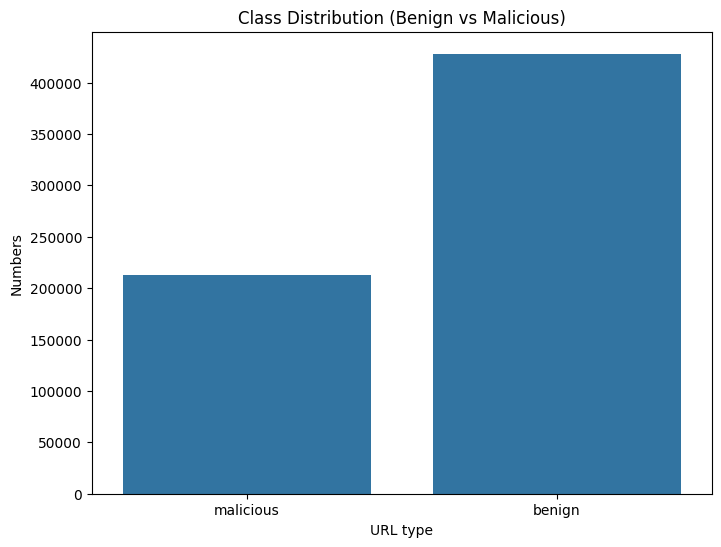

In [6]:
if 'df' in locals():
    plt.figure(figsize=(8, 6))
    sns.countplot(x='type', data=df)
    plt.title('Class Distribution (Benign vs Malicious)')
    plt.xlabel('URL type')
    plt.ylabel('Numbers')
    plt.show()

In [7]:
# Count Digits
def digit_count(url):
    return sum(c.isnumeric() for c in url)

In [8]:
# HTTPS Detection
def http_secure(url):
    return 1 if urlparse(url).scheme == 'https' else 0

In [9]:
# Number of Directories
def count_directories(url):
    return urlparse(url).path.count('/')

In [10]:
# Suspicious Keyword Detection
def suspicious_words(url):
    pattern = (
        r"PayPal|login|signin|bank|account|update|free|bonus|service|"
        r"ebayisapi|webscr|lucky|secure|verification|confirm"
    )
    return 1 if re.search(pattern, url, re.IGNORECASE) else 0

In [11]:
# First Directory Length
def first_dir_length(url):
    try:
        return len(urlparse(url).path.split('/')[1])
    except:
        return 0

In [12]:
# Top-Level Domain Length
def tld_length(url):
    try:
        tld = url.split('.')[-1]
        return len(tld) if tld else 0
    except:
        return 0

In [13]:
def count_www(url):
    url.count('www')
    return url.count('www')

In [14]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

In [15]:
def http(url):
    return 1 if urlparse(url).scheme == 'http' else 0

In [16]:
df["url_length"] = df["url"].apply(len)
df["http_secure"] = df["url"].apply(http_secure)
df["count_directories"] = df["url"].apply(count_directories)
df["first_dir_length"] = df["url"].apply(first_dir_length)
df["count_www"] = df["url"].apply(count_www)
df["count_dot"] = df["url"].apply(count_dot)
df["http"] = df["url"].apply(http)

In [17]:
df.head()

,url,type,url_length,http_secure,count_directories,first_dir_length,count_www,count_dot,http
0,br-icloud.com.br,malicious,16,0,0,0,0,2,0
1,mp3raid.com/music/krizz_kaliko.html,benign,35,0,2,5,0,2,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,31,0,3,7,0,2,0
3,http://www.garage-pirenne.be/index.php?option=...,malicious,88,0,1,9,1,3,1
4,http://adventure-nicaragua.net/index.php?optio...,malicious,235,0,1,9,0,2,1


In [18]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["type"])

In [19]:
label_map = {i: cls for i, cls in enumerate(le.classes_)}
print(label_map)

{0: 'benign', 1: 'malicious'}


In [20]:
df.head()

,url,type,url_length,http_secure,count_directories,first_dir_length,count_www,count_dot,http,label
0,br-icloud.com.br,malicious,16,0,0,0,0,2,0,1
1,mp3raid.com/music/krizz_kaliko.html,benign,35,0,2,5,0,2,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,31,0,3,7,0,2,0,0
3,http://www.garage-pirenne.be/index.php?option=...,malicious,88,0,1,9,1,3,1,1
4,http://adventure-nicaragua.net/index.php?optio...,malicious,235,0,1,9,0,2,1,1


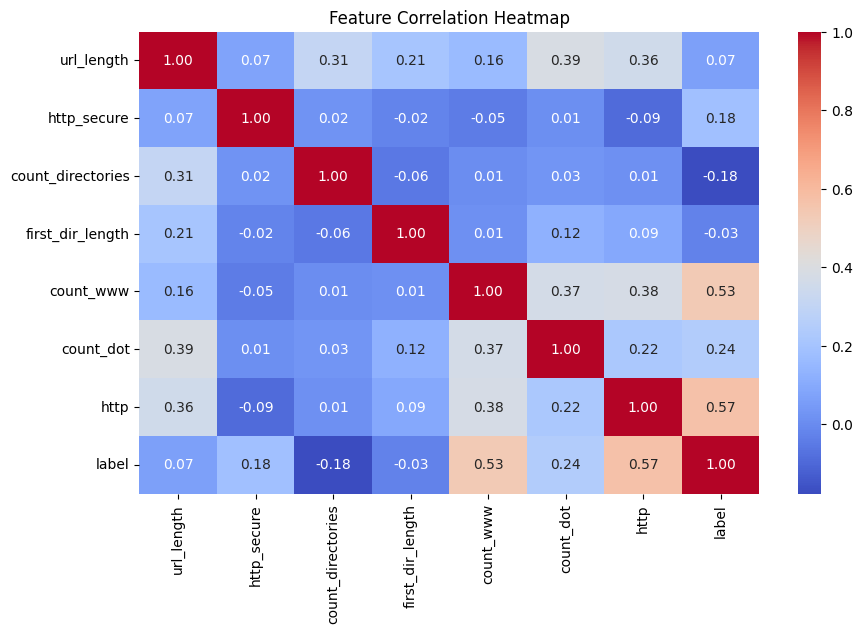

In [21]:
# --- Correlation Heatmap ---
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Feature Correlation Heatmap')
plt.show()

In [22]:
exclude_cols = ["url", "type"]
feature_cols = [col for col in df.columns if col not in exclude_cols + ["label"]]

X = df[feature_cols]
y = df["label"]

X.shape, y.shape

((641125, 7), (641125,))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

X_train.shape, X_test.shape

((512900, 7), (128225, 7))

In [24]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds), #(TP+TN)/All
        "Precision": precision_score(y_test, preds, average='macro'), #TP/(TP+FP)
        "Recall": recall_score(y_test, preds, average='macro'), #TP/(TP+FN)
        "F1 Score": f1_score(y_test, preds, average='macro') # Mean of precision & recall
    }

In [25]:
print("Evaluating Decision Tree...")

dt_model = DecisionTreeClassifier()
dt_result = evaluate_model(
    "Decision Tree",
    dt_model
)
y_pred = dt_model.predict(X_test)

dt_result

Evaluating Decision Tree...


{'Model': 'Decision Tree',
 'Accuracy': 0.9617937219730942,
 'Precision': 0.9610981077027017,
 'Recall': 0.9524855913475428,
 'F1 Score': 0.9565950807959377}

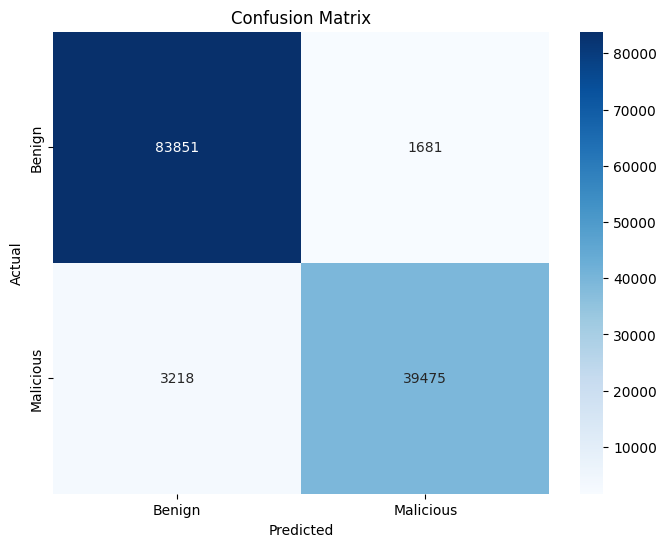

In [26]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Benign", "Malicious"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

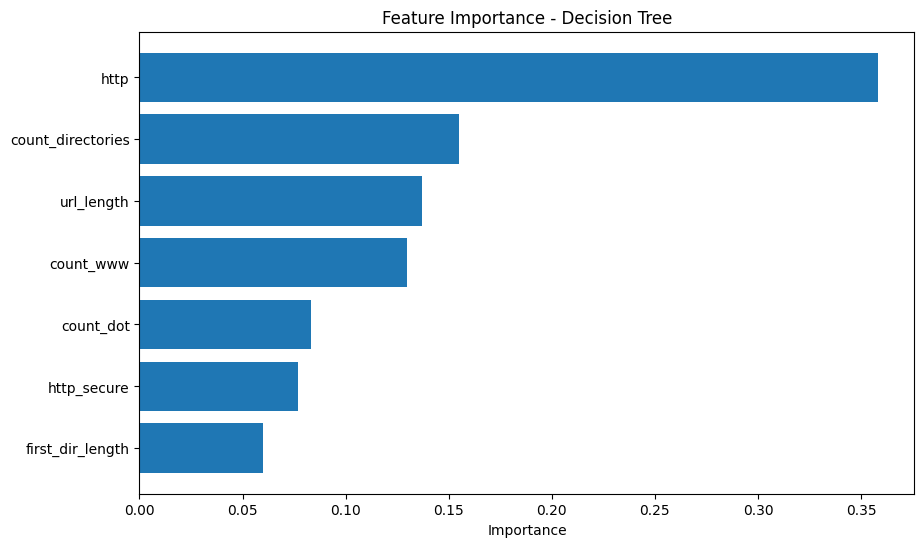

In [27]:
# Lấy độ quan trọng từ mô hình
importances = dt_model.feature_importances_
# Sắp xếp theo thứ tự giảm dần
indices = np.argsort(importances)[::-1]
names = [feature_cols[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Decision Tree")
plt.barh(range(X.shape[1]), importances[indices], align="center")
plt.yticks(range(X.shape[1]), names)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.show()

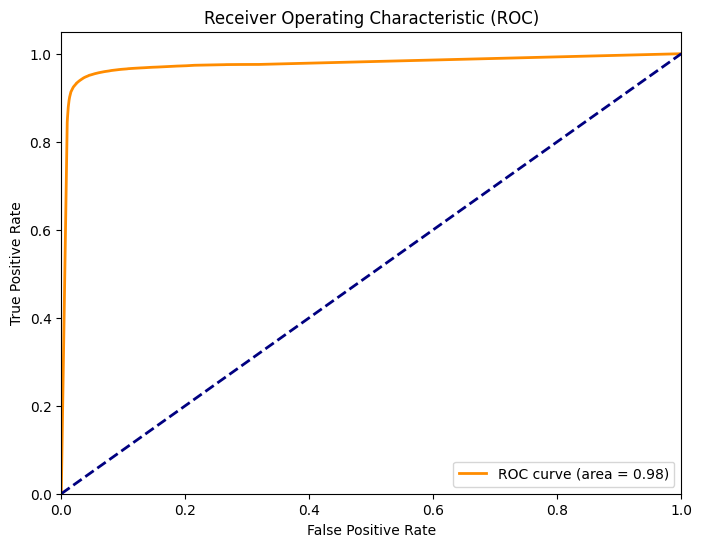

In [28]:
# --- 3. ROC Curve & AUC ---
from sklearn.metrics import roc_curve, auc

# Decision Tree có hỗ trợ predict_proba
y_probs = dt_model.predict_proba(X_test)[:, 1]

# Tính toán FPR và TPR
# TPR = TP/(TP+FN)
# FPR = FP/(FP+TN)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [29]:
import joblib

joblib.dump(dt_model, 'malicious_url_model.pkl')

['label_encoder.pkl']